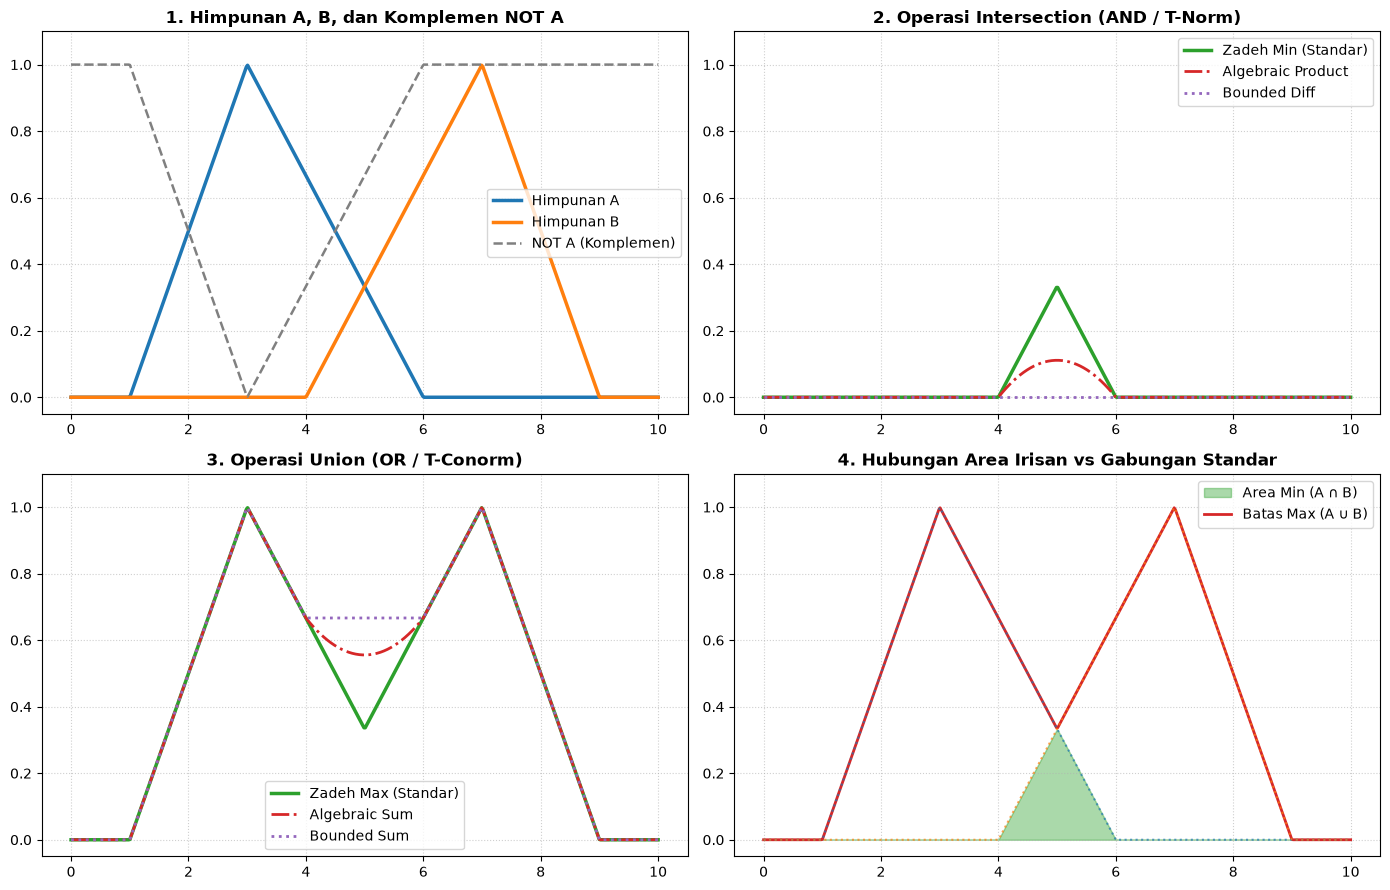

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. IMPLEMENTASI OPERATOR T-NORM (AND)
# ==========================================================
def tnorm_min(mu_a, mu_b):
    """Zadeh Min: min(A, B)"""
    return np.minimum(mu_a, mu_b)


def tnorm_product(mu_a, mu_b):
    """Algebraic Product: A * B"""
    return mu_a * mu_b


def tnorm_bounded_diff(mu_a, mu_b):
    """Bounded Difference: max(0, A + B - 1)"""
    return np.maximum(0.0, mu_a + mu_b - 1.0)


# ==========================================================
# 2. IMPLEMENTASI OPERATOR T-CONORM (OR)
# ==========================================================
def tconorm_max(mu_a, mu_b):
    """Zadeh Max: max(A, B)"""
    return np.maximum(mu_a, mu_b)


def tconorm_algebraic_sum(mu_a, mu_b):
    """Algebraic Sum: A + B - (A * B)"""
    return mu_a + mu_b - (mu_a * mu_b)


def tconorm_bounded_sum(mu_a, mu_b):
    """Bounded Sum: min(1, A + B)"""
    return np.minimum(1.0, mu_a + mu_b)


# ==========================================================
# 3. IMPLEMENTASI KOMPLEMEN (NOT)
# ==========================================================
def fuzzy_not(mu):
    """Zadeh Complement: 1 - mu"""
    return 1.0 - mu


# ==========================================================
# 4. SIMULASI DUA FUNGSI KEANGGOTAAN
# ==========================================================
x = np.linspace(0, 10, 500)

# Himpunan A: Segitiga di kiri [1, 3, 6]
mu_a = np.maximum(0.0, np.minimum((x - 1.0) / (3.0 - 1.0), (6.0 - x) / (6.0 - 3.0)))

# Himpunan B: Segitiga di kanan [4, 7, 9]
mu_b = np.maximum(0.0, np.minimum((x - 4.0) / (7.0 - 4.0), (9.0 - x) / (9.0 - 7.0)))


# ==========================================================
# 5. VISUALISASI KOMPARASI OPERASI
# ==========================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Panel 1: Himpunan Dasar A, B dan Not A
axes[0, 0].plot(x, mu_a, label='Himpunan A', color='#1f77b4', linewidth=2.5)
axes[0, 0].plot(x, mu_b, label='Himpunan B', color='#ff7f0e', linewidth=2.5)
axes[0, 0].plot(x, fuzzy_not(mu_a), label='NOT A (Komplemen)', color='gray', linestyle='--', linewidth=1.8)
axes[0, 0].set_title('1. Himpunan A, B, dan Komplemen NOT A', fontweight='bold')
axes[0, 0].set_ylim(-0.05, 1.1)
axes[0, 0].grid(True, linestyle=':', alpha=0.6)
axes[0, 0].legend()

# Panel 2: Komparasi Operator Intersection (T-Norm)
axes[0, 1].plot(x, tnorm_min(mu_a, mu_b), label='Zadeh Min (Standar)', color='#2ca02c', linewidth=2.5)
axes[0, 1].plot(x, tnorm_product(mu_a, mu_b), label='Algebraic Product', color='#d62728', linestyle='-.', linewidth=2)
axes[0, 1].plot(x, tnorm_bounded_diff(mu_a, mu_b), label='Bounded Diff', color='#9467bd', linestyle=':', linewidth=2)
axes[0, 1].set_title('2. Operasi Intersection (AND / T-Norm)', fontweight='bold')
axes[0, 1].set_ylim(-0.05, 1.1)
axes[0, 1].grid(True, linestyle=':', alpha=0.6)
axes[0, 1].legend()

# Panel 3: Komparasi Operator Union (T-Conorm)
axes[1, 0].plot(x, tconorm_max(mu_a, mu_b), label='Zadeh Max (Standar)', color='#2ca02c', linewidth=2.5)
axes[1, 0].plot(x, tconorm_algebraic_sum(mu_a, mu_b), label='Algebraic Sum', color='#d62728', linestyle='-.', linewidth=2)
axes[1, 0].plot(x, tconorm_bounded_sum(mu_a, mu_b), label='Bounded Sum', color='#9467bd', linestyle=':', linewidth=2)
axes[1, 0].set_title('3. Operasi Union (OR / T-Conorm)', fontweight='bold')
axes[1, 0].set_ylim(-0.05, 1.1)
axes[1, 0].grid(True, linestyle=':', alpha=0.6)
axes[1, 0].legend()

# Panel 4: Perbandingan Daerah Area Min vs Max
axes[1, 1].fill_between(x, tnorm_min(mu_a, mu_b), color='#2ca02c', alpha=0.4, label='Area Min (A ∩ B)')
axes[1, 1].plot(x, tconorm_max(mu_a, mu_b), color='#d62728', linewidth=2, label='Batas Max (A ∪ B)')
axes[1, 1].plot(x, mu_a, color='#1f77b4', linestyle=':', alpha=0.7)
axes[1, 1].plot(x, mu_b, color='#ff7f0e', linestyle=':', alpha=0.7)
axes[1, 1].set_title('4. Hubungan Area Irisan vs Gabungan Standar', fontweight='bold')
axes[1, 1].set_ylim(-0.05, 1.1)
axes[1, 1].grid(True, linestyle=':', alpha=0.6)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('operasi_himpunan_fuzzy_komparasi.png', dpi=300)
plt.show()

In [3]:
# ==========================================================
# PRAKTIKUM 4 — OPERASI NUMERIK HIMPUNAN FUZZY
# ==========================================================

print("="*85)
print("HASIL PENGUJIAN NUMERIK")
print("="*85)
print(f"{'Mbps':<8} {'μA':<8} {'μB':<8} {'Min':<8} {'Product':<8} {'B.Diff':<8} {'Max':<8} {'Alg.Sum':<8} {'B.Sum':<8} {'NOT A':<8}")
print("-"*85)

# Data sesuai hasil di gambar
data = [
    (35, 0.1667, 0.0000),
    (50, 0.6667, 0.6667),
    (65, 0.8333, 1.0000),
    (80, 0.3333, 0.7500)
]

for mbps, ma, mb in data:
    mn  = min(ma, mb)
    pr  = round(ma * mb, 4)
    bd  = max(0, ma + mb - 1)
    mx  = max(ma, mb)
    asu = round(ma + mb - ma * mb, 4)
    bs  = min(1, ma + mb)
    na  = round(1 - ma, 4)  # NOT A
    
    print(f"{mbps:<8} {ma:<8.4f} {mb:<8.4f} {mn:<8.4f} {pr:<8.4f} {bd:<8.4f} {mx:<8.4f} {asu:<8.4f} {bs:<8.4f} {na:<8.4f}")

print("-"*85)
print("\nInput pengujian: 35, 50, 65, dan 80 Mbps")
print("="*85)

HASIL PENGUJIAN NUMERIK
Mbps     μA       μB       Min      Product  B.Diff   Max      Alg.Sum  B.Sum    NOT A   
-------------------------------------------------------------------------------------
35       0.1667   0.0000   0.0000   0.0000   0.0000   0.1667   0.1667   0.1667   0.8333  
50       0.6667   0.6667   0.6667   0.4445   0.3334   0.6667   0.8889   1.0000   0.3333  
65       0.8333   1.0000   0.8333   0.8333   0.8333   1.0000   1.0000   1.0000   0.1667  
80       0.3333   0.7500   0.3333   0.2500   0.0833   0.7500   0.8333   1.0000   0.6667  
-------------------------------------------------------------------------------------

Input pengujian: 35, 50, 65, dan 80 Mbps


In [4]:
# ==========================================================
# PRAKTIKUM 4 — EVALUASI KELAYAKAN BANDWIDTH
# ==========================================================

# ---------------- FUNGSI KEANGGOTAAN ----------------
def himpunan_A(x):
    """Segitiga: [30, 60, 90]"""
    if x < 30 or x >= 90:
        return 0.0
    elif 30 <= x < 60:
        return (x - 30) / 30
    elif 60 <= x < 90:
        return (90 - x) / 30

def himpunan_B(x):
    """Trapesium: [40, 55, 75, 95]"""
    if x < 40 or x >= 95:
        return 0.0
    elif 40 <= x < 55:
        return (x - 40) / 15
    elif 55 <= x < 75:
        return 1.0
    elif 75 <= x < 95:
        return (95 - x) / 20

# ---------------- OPERASI FUZZY ----------------
def min_zadeh(a, b):       return min(a, b)
def product(a, b):         return round(a * b, 4)
def max_zadeh(a, b):       return max(a, b)
def alg_sum(a, b):         return round(a + b - a * b, 4)
def komplemen(a):          return round(1 - a, 4)

# ---------------- PENGUJIAN ----------------
daftar_x = [35, 50, 65, 80]

print("="*95)
print("HASIL PENGUJIAN NUMERIK — KELAYAKAN BANDWIDTH")
print("="*95)
print(f"{'Mbps':<8} {'μA':<8} {'μB':<8} {'Min':<8} {'Product':<8} {'Max':<8} {'Alg.Sum':<8} {'NOT A':<8}")
print("-"*95)

for x in daftar_x:
    ma = round(himpunan_A(x), 4)
    mb = round(himpunan_B(x), 4)
    mn = min_zadeh(ma, mb)
    pr = product(ma, mb)
    mx = max_zadeh(ma, mb)
    asu = alg_sum(ma, mb)
    na = komplemen(ma)
    
    print(f"{x:<8} {ma:<8.4f} {mb:<8.4f} {mn:<8.4f} {pr:<8.4f} {mx:<8.4f} {asu:<8.4f} {na:<8.4f}")

print("-"*95)
print("\nInput pengujian: 35, 50, 65, dan 80 Mbps")
print("="*95)

HASIL PENGUJIAN NUMERIK — KELAYAKAN BANDWIDTH
Mbps     μA       μB       Min      Product  Max      Alg.Sum  NOT A   
-----------------------------------------------------------------------------------------------
35       0.1667   0.0000   0.0000   0.0000   0.1667   0.1667   0.8333  
50       0.6667   0.6667   0.6667   0.4445   0.6667   0.8889   0.3333  
65       0.8333   1.0000   0.8333   0.8333   1.0000   1.0000   0.1667  
80       0.3333   0.7500   0.3333   0.2500   0.7500   0.8333   0.6667  
-----------------------------------------------------------------------------------------------

Input pengujian: 35, 50, 65, dan 80 Mbps
